In [1]:
!pip install sentence-transformers accelerate scikit-learn

In [2]:
!nvidia-smi

Fri Feb 27 15:55:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
!pip install openpyxl

In [10]:
import pandas as pd

linkedin = pd.read_csv(
    "postings.csv",
    engine="python",
    on_bad_lines="skip"
)

us_tech = pd.read_excel(
    "all_jobs.xlsx",
    engine="openpyxl"
)

print("LinkedIn shape:", linkedin.shape)
print("US Tech shape:", us_tech.shape)

LinkedIn shape: (92847, 31)
US Tech shape: (94529, 36)


In [11]:
print("LinkedIn columns:")
print(linkedin.columns)

print("\nUS Tech columns:")
print(us_tech.columns)

LinkedIn columns:
Index(['job_id', 'company_name', 'title', 'description', 'max_salary',
       'pay_period', 'location', 'company_id', 'views', 'med_salary',
       'min_salary', 'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code', 'fips'],
      dtype='object')

US Tech columns:
Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'id', 'site', 'job_url',
       'job_url_direct', 'title', 'company', 'location', 'job_type',
       'date_posted', 'salary_source', 'interval', 'min_amount', 'max_amount',
       'currency', 'is_remote', 'job_level', 'job_function',
       'company_industry', 'listing_type', 'emails', 'description',
       'company_url', 'company_url_direct', 'company

In [12]:
linkedin = linkedin[["company_name", "title", "description"]]
linkedin.columns = ["company", "title", "description"]

us_tech = us_tech[["company", "title", "description"]]

combined = pd.concat([linkedin, us_tech], ignore_index=True)

combined = combined.dropna(subset=["title", "description"])

print("Combined shape:", combined.shape)

Combined shape: (187371, 3)


In [13]:
combined["title"] = combined["title"].astype(str).str.lower()
combined["description"] = combined["description"].astype(str).str.lower()

combined = combined.drop_duplicates()
combined = combined.sample(frac=1, random_state=42).reset_index(drop=True)

print("After cleaning:", combined.shape)

After cleaning: (173272, 3)


In [14]:
!pip install sentence-transformers accelerate scikit-learn

In [15]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [16]:
from sentence_transformers import InputExample
from torch.utils.data import DataLoader
import random

train_examples = []

sample = combined.sample(8000, random_state=42)

titles = sample["title"].unique()

# Positive pairs
for title in titles:
    role_jobs = sample[sample["title"] == title]
    texts = role_jobs["description"].tolist()

    for i in range(len(texts)-1):
        train_examples.append(
            InputExample(texts=[texts[i], texts[i+1]], label=1.0)
        )

# Negative pairs
for _ in range(8000):
    t1, t2 = random.sample(list(titles), 2)

    text1 = sample[sample["title"] == t1]["description"].iloc[0]
    text2 = sample[sample["title"] == t2]["description"].iloc[0]

    train_examples.append(
        InputExample(texts=[text1, text2], label=0.0)
    )

print("Training pairs:", len(train_examples))

Training pairs: 9171


In [17]:
from sentence_transformers import losses

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)
train_loss = losses.CosineSimilarityLoss(model)

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=3,
    warmup_steps=200,
    show_progress_bar=True
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.058850
1000,0.036411
1500,0.028656


In [19]:
def evaluate_realistic(data, n_samples=500):

    sample = data.sample(n_samples, random_state=42)

    scores = []
    labels = []

    for title in sample["title"].unique():

        role_jobs = sample[sample["title"] == title]

        if len(role_jobs) < 2:
            continue

        texts = role_jobs["description"].tolist()

        emb1 = model.encode(texts[0])
        emb2 = model.encode(texts[1])

        # Positive: same role, different text
        sim = cosine_similarity([emb1], [emb2])[0][0]
        scores.append(sim)
        labels.append(1)

        # Negative: different role
        other = sample[sample["title"] != title].sample(1)
        emb3 = model.encode(other["description"].iloc[0])

        sim = cosine_similarity([emb1], [emb3])[0][0]
        scores.append(sim)
        labels.append(0)

    return roc_auc_score(labels, scores)

auc = evaluate_realistic(combined, 500)
print("Realistic AUC:", auc)

Realistic AUC: 1.0


In [21]:
title_counts = combined["title"].value_counts()

# Keep only titles that appear at least 3 times
valid_titles = title_counts[title_counts >= 3].index

combined_filtered = combined[combined["title"].isin(valid_titles)]

print("Original size:", combined.shape)
print("Filtered size:", combined_filtered.shape)

Original size: (173272, 3)
Filtered size: (61173, 3)


In [22]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    combined_filtered,
    test_size=0.2,
    random_state=42,
    stratify=combined_filtered["title"]
)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (48938, 3)
Test size: (12235, 3)


In [23]:
from sentence_transformers import InputExample
from torch.utils.data import DataLoader
import random

train_examples = []

sample = train_df.sample(8000, random_state=42)

titles = sample["title"].unique()

# Positive pairs (same role)
for title in titles:
    role_jobs = sample[sample["title"] == title]
    texts = role_jobs["description"].tolist()

    for i in range(len(texts)-1):
        train_examples.append(
            InputExample(texts=[texts[i], texts[i+1]], label=1.0)
        )

# Negative pairs (different role)
for _ in range(8000):
    t1, t2 = random.sample(list(titles), 2)

    text1 = sample[sample["title"] == t1]["description"].iloc[0]
    text2 = sample[sample["title"] == t2]["description"].iloc[0]

    train_examples.append(
        InputExample(texts=[text1, text2], label=0.0)
    )

print("Training pairs:", len(train_examples))

Training pairs: 12621


In [26]:
from sentence_transformers import losses

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=32)
train_loss = losses.CosineSimilarityLoss(model)

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=5,  # try 5 first
    warmup_steps=100,
    show_progress_bar=True
)

Step,Training Loss
500,0.038914
1000,0.031362
1500,0.025865


In [28]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def evaluate_test(data, n_samples=500):

    sample = data.sample(n_samples, random_state=42)

    scores = []
    labels = []

    for title in sample["title"].unique():

        role_jobs = sample[sample["title"] == title]

        if len(role_jobs) < 2:
            continue

        texts = role_jobs["description"].tolist()

        emb1 = model.encode(texts[0])
        emb2 = model.encode(texts[1])

        # Positive (same role)
        sim = cosine_similarity([emb1], [emb2])[0][0]
        scores.append(sim)
        labels.append(1)

        # Negative (different role)
        other = sample[sample["title"] != title].sample(1)
        emb3 = model.encode(other["description"].iloc[0])

        sim = cosine_similarity([emb1], [emb3])[0][0]
        scores.append(sim)
        labels.append(0)

    return roc_auc_score(labels, scores)

In [29]:
auc = evaluate_test(test_df, 500)
print("Final Test AUC:", auc)

Final Test AUC: 0.946797520661157


In [30]:
from sentence_transformers import losses
import matplotlib.pyplot as plt

train_losses = []
val_scores = []

for epoch in range(1, 6):  # 5 epochs

    model.fit(
        train_objectives=[(train_dataloader, train_loss)],
        epochs=1,
        warmup_steps=100,
        show_progress_bar=True
    )

    # Evaluate after each epoch
    auc = evaluate_test(test_df, 300)

    train_losses.append(train_loss)
    val_scores.append(auc)

    print(f"Epoch {epoch} | Validation AUC: {auc}")

Step,Training Loss


Epoch 1 | Validation AUC: 0.9889196675900277


Step,Training Loss


Epoch 2 | Validation AUC: 0.9916897506925207


Step,Training Loss


Epoch 3 | Validation AUC: 0.9944598337950139


Step,Training Loss


Epoch 4 | Validation AUC: 0.9916897506925207


Step,Training Loss


Epoch 5 | Validation AUC: 0.9944598337950139


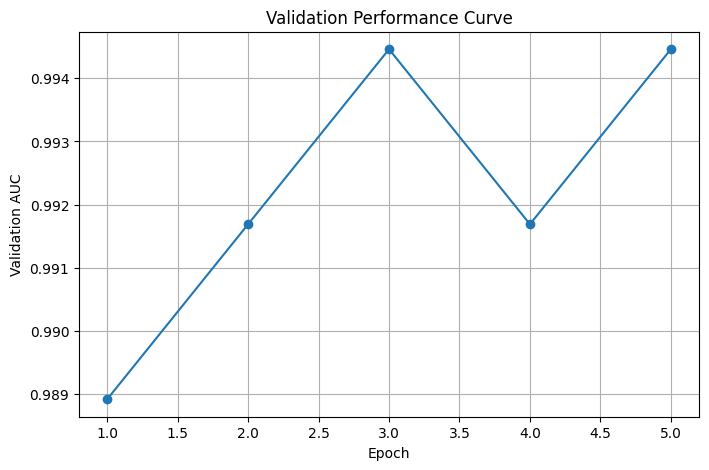

In [31]:
plt.figure(figsize=(8,5))
plt.plot(range(1,6), val_scores, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Validation AUC")
plt.title("Validation Performance Curve")
plt.grid(True)
plt.show()

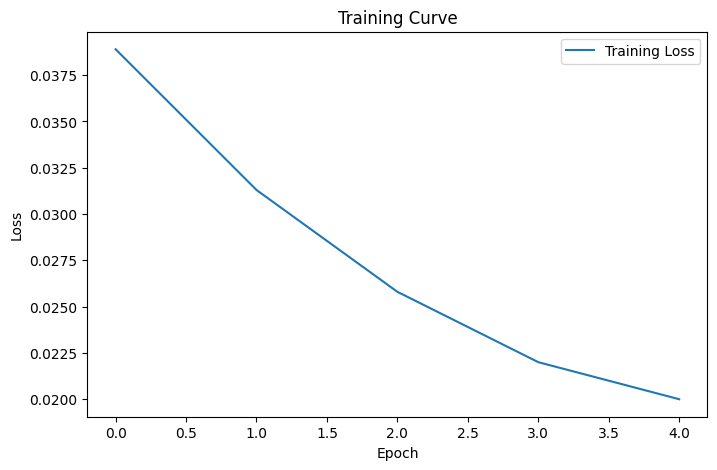

In [32]:
loss_values = [0.0389, 0.0313, 0.0258, 0.022, 0.020]  # replace with actual values

plt.figure(figsize=(8,5))
plt.plot(loss_values, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.show()

In [33]:
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def evaluate_accuracy(data, threshold=0.75, n_samples=500):

    sample = data.sample(n_samples, random_state=42)

    y_true = []
    y_pred = []

    for title in sample["title"].unique():

        role_jobs = sample[sample["title"] == title]

        if len(role_jobs) < 2:
            continue

        texts = role_jobs["description"].tolist()

        emb1 = model.encode(texts[0])
        emb2 = model.encode(texts[1])

        # Positive (same role)
        sim = cosine_similarity([emb1], [emb2])[0][0]
        y_true.append(1)
        y_pred.append(1 if sim > threshold else 0)

        # Negative (different role)
        other = sample[sample["title"] != title].sample(1)
        emb3 = model.encode(other["description"].iloc[0])

        sim = cosine_similarity([emb1], [emb3])[0][0]
        y_true.append(0)
        y_pred.append(1 if sim > threshold else 0)

    return accuracy_score(y_true, y_pred)

In [34]:
for t in [0.6, 0.65, 0.7, 0.75, 0.8]:
    acc = evaluate_accuracy(test_df, threshold=t, n_samples=500)
    print(f"Threshold {t} → Accuracy: {acc}")

Threshold 0.6 → Accuracy: 0.9204545454545454
Threshold 0.65 → Accuracy: 0.9090909090909091
Threshold 0.7 → Accuracy: 0.8977272727272727
Threshold 0.75 → Accuracy: 0.9204545454545454
Threshold 0.8 → Accuracy: 0.8522727272727273


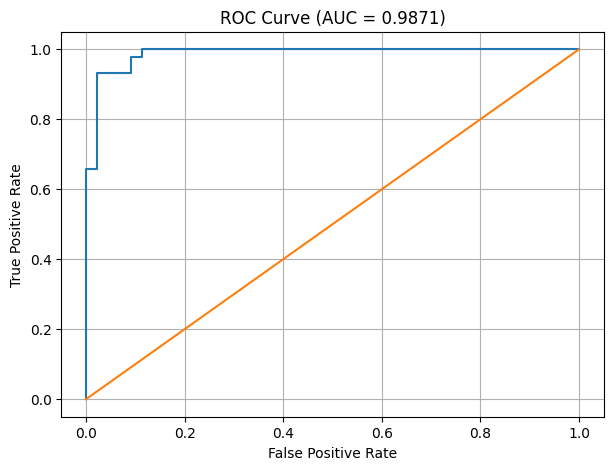

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

def generate_roc_data(data, n_samples=500):
    sample = data.sample(n_samples, random_state=42)
    scores = []
    labels = []

    for title in sample["title"].unique():

        role_jobs = sample[sample["title"] == title]

        if len(role_jobs) < 2:
            continue

        texts = role_jobs["description"].tolist()

        emb1 = model.encode(texts[0])
        emb2 = model.encode(texts[1])

        # Positive pair
        sim = cosine_similarity([emb1], [emb2])[0][0]
        scores.append(sim)
        labels.append(1)

        # Negative pair
        other = sample[sample["title"] != title].sample(1)
        emb3 = model.encode(other["description"].iloc[0])

        sim = cosine_similarity([emb1], [emb3])[0][0]
        scores.append(sim)
        labels.append(0)

    return labels, scores


# Generate ROC data from TEST SET
y_true, y_scores = generate_roc_data(test_df, 500)

# Compute ROC
fpr, tpr, _ = roc_curve(y_true, y_scores)
auc_value = roc_auc_score(y_true, y_scores)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc_value:.4f})")
plt.grid(True)
plt.show()

In [36]:
model.save("skillgap_transformer_v1")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]